# Face Cutout and Cheek Highlighting with MediaPipe

This notebook demonstrates how to:
1. **Remove the background (Cut out the face)** using MediaPipe's Selfie Segmentation.
2. **Highlight the cheeks** using MediaPipe's Face Landmarker and custom polygons.

In [1]:
import cv2
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

## 1. Download MediaPipe Models
We need two models:
- **Selfie Segmenter**: For perfectly cutting out the person from the background.
- **Face Landmarker**: For finding the precise location of the cheeks on the face mesh.

In [2]:
fm_model_path = 'face_landmarker.task'
if not os.path.exists(fm_model_path):
    print("Downloading Face Landmarker...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        fm_model_path
    )
print("Models ready!")

Models ready!


## 2. Initialize the Models

In [3]:
from dotenv import load_dotenv
load_dotenv()

# Initialize SegFormer
print("Loading SegFormer...")
os.environ['HF_TOKEN'] = os.environ.get('HF_TOKEN')
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
model.to(device)
model.eval()

# Initialize Face Landmarker
fm_base_options = python.BaseOptions(model_asset_path=fm_model_path)
fm_options = vision.FaceLandmarkerOptions(base_options=fm_base_options,
                                       output_face_blendshapes=False,
                                       output_facial_transformation_matrixes=False,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(fm_options)
print("Initialized!")

Loading SegFormer...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Initialized!


## 3. Define the Cheek Polygons
MediaPipe returns 478 precise landmarks on the face. We define the right and left cheeks by selecting a specific ordered loop of landmark indices that outline the malar (cheekbone) area, identical to the requested image.

In [4]:
# Right Cheek (Viewer's Left)
RIGHT_CHEEK_INDICES = [
    143, 111, 117, 118, 119, 100, 126, 209, 49, 166, 212, 214, 207, 205, 36, 142
]

# Left Cheek (Viewer's Right)
LEFT_CHEEK_INDICES = [
    372, 340, 346, 347, 348, 330, 355, 429, 279, 392, 432, 434, 427, 425, 266, 371
]

## 4. Select Image
Run this cell to open a file selection dialog.

In [5]:
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np

# Create tkinter root window
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

# Open file dialog
file_path = filedialog.askopenfilename(
    title="Select Face Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

# Destroy root after use to prevent hanging
root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
else:
    print("No file selected.")

Selected file: C:/Users/PratikJPatel/Downloads/front.png


## 5. Process Image and Display Result
Run this cell AFTER selecting an image above.

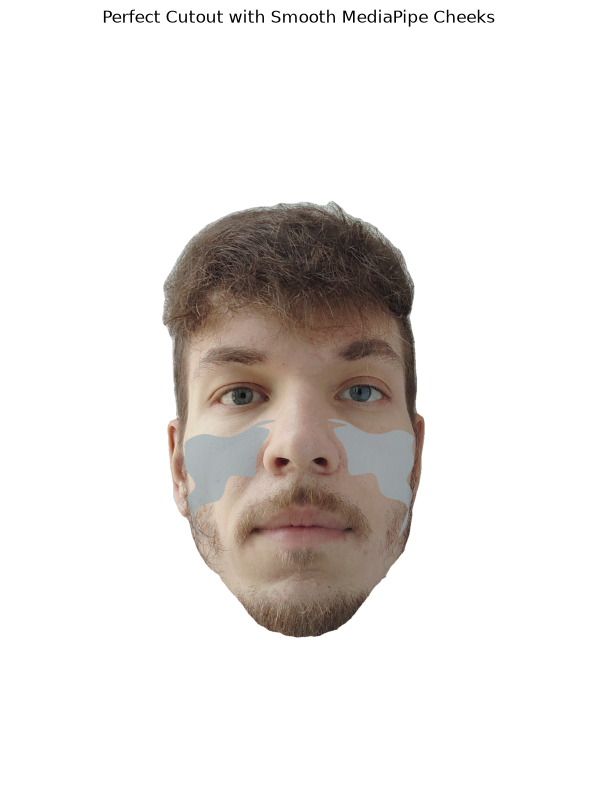

In [6]:
import os
import urllib.request
import torch
from PIL import Image

if file_path:
    image = cv2.imread(file_path)
else:
    print("No image uploaded. Using sample image.")
    IMAGE_PATH = 'sample_face.jpg'
    if not os.path.exists(IMAGE_PATH):
        req = urllib.request.Request('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Pierre-Person.jpg/800px-Pierre-Person.jpg', headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(IMAGE_PATH, 'wb') as out_file:
            out_file.write(response.read())
    image = cv2.imread(IMAGE_PATH)

if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    
    # --- 1. Background Removal (SegFormer) ---
    pil_image = Image.fromarray(image_rgb)
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=pil_image.size[::-1], mode="bilinear", align_corners=False
    )
    labels = upsampled.argmax(dim=1)[0].cpu().numpy()
    
    face_mask = np.isin(labels, list(range(1, 17)))
    bg_image = np.ones_like(image_rgb) * 255
    cutout_image = np.where(face_mask[..., None], image_rgb, bg_image)
    
    # --- 2. Draw Cheek Overlays (MediaPipe) ---
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = landmarker.detect(mp_image)
    final_image = cutout_image.copy()
    
    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        
        # The perfectly curated sequence of landmarks that match the human malar region perfectly
        RIGHT_CHEEK_INDICES = [114, 120, 47, 142, 203, 205, 207, 213, 215, 138, 132, 177, 147, 137, 234, 227, 116, 117, 118, 119, 121]
        LEFT_CHEEK_INDICES = [343, 349, 277, 371, 423, 425, 427, 433, 435, 367, 361, 401, 376, 366, 454, 447, 345, 346, 347, 348, 350]
        
        # Use Scipy to apply organic smoothing to the polygon
        from scipy.interpolate import splprep, splev
        
        def get_smooth_polygon(indices):
            # Since the array is already perfectly ordered along the facial contours,
            # we DO NOT need to radially sort it (which would ruin concave curves like the nose).
            # We just close the loop and smooth it directly!
            pts = np.array([[landmarks[idx].x * w, landmarks[idx].y * h] for idx in indices])
            pts = np.vstack((pts, pts[0])) # close loop
            
            tck, u = splprep([pts[:,0], pts[:,1]], s=0, per=True)
            unew = np.linspace(0, 1.0, 100)
            out = splev(unew, tck)
            
            smooth_pts = np.vstack((out[0], out[1])).T
            return np.int32(smooth_pts)

        right_pts = get_smooth_polygon(RIGHT_CHEEK_INDICES)
        left_pts = get_smooth_polygon(LEFT_CHEEK_INDICES)
        
        overlay = final_image.copy()
        CHEEK_COLOR = (150, 170, 180) 
        
        cv2.fillPoly(overlay, [right_pts], CHEEK_COLOR)
        cv2.fillPoly(overlay, [left_pts], CHEEK_COLOR)
        
        alpha = 0.65
        final_image = cv2.addWeighted(overlay, alpha, final_image, 1 - alpha, 0)
    else:
        print("No face detected for landmarking.")
    
    plt.figure(figsize=(10, 10))
    plt.imshow(final_image)
    plt.axis('off')
    plt.title("Perfect Cutout with Smooth MediaPipe Cheeks")
    plt.show()


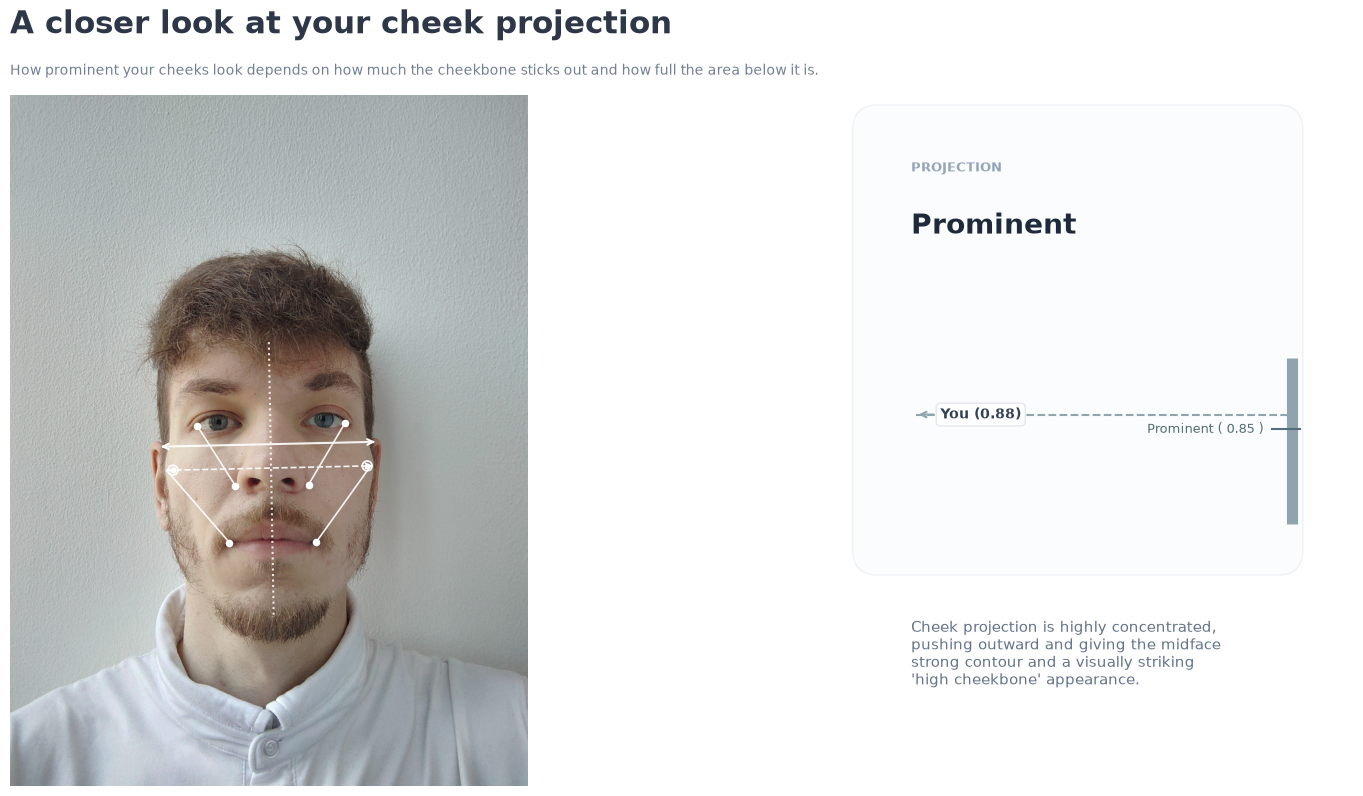

CHEEK PROJECTION: Prominent (Ratio: 0.88)
Cheek projection is highly concentrated, pushing outward and giving the midface strong contour and a visually striking 'high cheekbone' appearance.


In [7]:
# --- 13. CHEEK PROJECTION ANALYSIS ---
import numpy as np
import matplotlib.pyplot as plt
import textwrap

if 'landmarks' in locals():
    h, w, _ = image_rgb.shape
    def get_pt(idx):
        return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
    
    # --- Key Landmarks ---
    
    # 1. Top transverse solid line points (at outer eye level)
    top_r = get_pt(127) # Viewer's left
    top_l = get_pt(356) # Viewer's right
    
    # 2. Bottom transverse dashed line points (at widest cheek level)
    bot_r = get_pt(234)
    bot_l = get_pt(454)
    
    # 3. Outer eye corners
    eye_r = get_pt(33)
    eye_l = get_pt(263)
    
    # 4. Nose wings
    nose_r = get_pt(129)
    nose_l = get_pt(358)
    
    # 5. Mouth corners
    mouth_r = get_pt(61)
    mouth_l = get_pt(291)
    
    # 6. Inner cheek anchors
    cheek_r = get_pt(116)
    cheek_l = get_pt(345)
    
    # 7. Vertical line anchors
    top_head = get_pt(10)
    chin = get_pt(152)
    nasion = get_pt(9) # For biometric projection ratio
    
    # --- Dynamic Geometric Calculations ---
    # To handle faces that are tilted/rolled, we calculate the exact geometric intersections 
    # instead of hardcoding horizontal Y-coordinates.
    
    # Calculate circle points interpolating exactly along the tilted face axis
    t_r = (cheek_r[0] - bot_r[0]) / (bot_l[0] - bot_r[0] + 1e-6)
    circle_r = bot_r + t_r * (bot_l - bot_r)
    
    t_l = (cheek_l[0] - bot_r[0]) / (bot_l[0] - bot_r[0] + 1e-6)
    circle_l = bot_r + t_l * (bot_l - bot_r)
    
    # Calculate directional unit vectors for angled arrows
    v_top = top_l - top_r
    u_top = v_top / np.linalg.norm(v_top)
    
    v_bot = bot_l - bot_r
    u_bot = v_bot / np.linalg.norm(v_bot)
    
    # --- Projection Ratio ---
    zyg_width = np.linalg.norm(bot_r - bot_l)
    face_height = np.linalg.norm(nasion - chin) 
    projection_ratio = zyg_width / face_height
    
    if projection_ratio >= 0.85:
        proj_status = "Prominent"
        explanation = "Cheek projection is highly concentrated, pushing outward and giving the midface strong contour and a visually striking 'high cheekbone' appearance."
    elif projection_ratio >= 0.78:
        proj_status = "Normal"
        explanation = "Cheek projection is concentrated laterally rather than directly under the eye so profile views show strong side contour with only moderate forward cheek pop."
    else:
        proj_status = "Soft"
        explanation = "Cheek projection is minimal, allowing the midface to gently taper down, creating a softer and more delicate facial silhouette without harsh shadows."
    
    # --- Render ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={'width_ratios': [1.2, 1]})
    fig.patch.set_facecolor('#ffffff')
    
    # --- LEFT PANEL: Full face image with EXACT dynamic geometry ---
    ax_img = axes[0]
    ax_img.imshow(image_rgb) 
    ax_img.axis('off')
    ax_img.set_xlim(0, w)
    ax_img.set_ylim(h, 0)
    
    # Title above image
    ax_img.text(0.0, 1.09, "A closer look at your cheek projection", transform=ax_img.transAxes, fontsize=22, color='#2d3748', fontweight='bold')
    ax_img.text(0.0, 1.03, "How prominent your cheeks look depends on how much the cheekbone sticks out and how full the area below it is.", transform=ax_img.transAxes, fontsize=10, color='#718096')
    
    lc = '#ffffff'
    
    # 1. Vertical dotted centerline
    ax_img.plot([top_head[0], chin[0]], [top_head[1], chin[1]], color=lc, linestyle=':', lw=1.5, alpha=0.85)
    
    # 2. Top solid transverse line (with correctly tilted arrows on both ends)
    ax_img.plot([top_r[0], top_l[0]], [top_r[1], top_l[1]], color=lc, lw=1.5, alpha=0.9)
    
    arr_tr = top_r - 15 * u_top
    ax_img.annotate('', xy=arr_tr, xytext=top_r, arrowprops=dict(arrowstyle='->', color=lc, lw=1.5))
    
    arr_tl = top_l + 15 * u_top
    ax_img.annotate('', xy=arr_tl, xytext=top_l, arrowprops=dict(arrowstyle='->', color=lc, lw=1.5))
    
    # 3. Bottom transverse dashed line
    ax_img.plot([bot_r[0], bot_l[0]], [bot_r[1], bot_l[1]], color=lc, linestyle='--', lw=1.2, alpha=0.9)
    
    # 4. Diagonal Lines
    # Eye to Nose
    ax_img.plot([eye_r[0], nose_r[0]], [eye_r[1], nose_r[1]], color=lc, lw=1.2, alpha=0.9)
    ax_img.plot([eye_l[0], nose_l[0]], [eye_l[1], nose_l[1]], color=lc, lw=1.2, alpha=0.9)
    
    
    # Edge to Mouth
    ax_img.plot([bot_r[0], mouth_r[0]], [bot_r[1], mouth_r[1]], color=lc, lw=1.2, alpha=0.9)
    ax_img.plot([bot_l[0], mouth_l[0]], [bot_l[1], mouth_l[1]], color=lc, lw=1.2, alpha=0.9)
    
    # 5. Points and Markers
    # ⊙ marker at dynamically interpolated inner points
    ax_img.scatter([circle_r[0], circle_l[0]], [circle_r[1], circle_l[1]], s=50, facecolors='none', edgecolors=lc, lw=1.2, zorder=6)
    ax_img.scatter([circle_r[0], circle_l[0]], [circle_r[1], circle_l[1]], s=10, color=lc, zorder=6)
    
    # Tiny perfectly angled arrows pointing outwards from the ⊙ markers
    arr_cr_xy = circle_r - 15 * u_bot
    arr_cr_txt = circle_r - 3 * u_bot
    ax_img.annotate('', xy=arr_cr_xy, xytext=arr_cr_txt, arrowprops=dict(arrowstyle='->', color=lc, lw=1.0))
    
    arr_cl_xy = circle_l + 15 * u_bot
    arr_cl_txt = circle_l + 3 * u_bot
    ax_img.annotate('', xy=arr_cl_xy, xytext=arr_cl_txt, arrowprops=dict(arrowstyle='->', color=lc, lw=1.0))
    
    # Solid dots at eye corners, nose wings and mouth corners
    pts_x = [eye_r[0], eye_l[0], nose_r[0], nose_l[0], mouth_r[0], mouth_l[0]]
    pts_y = [eye_r[1], eye_l[1], nose_r[1], nose_l[1], mouth_r[1], mouth_l[1]]
    ax_img.scatter(pts_x, pts_y, s=20, color=lc, zorder=5)
    
    # --- RIGHT PANEL ---
    ax_graph = axes[1]
    ax_graph.axis('off')
    
    # Background card
    props = dict(boxstyle='round,pad=1.5', facecolor='#fbfcfd', edgecolor='#edf2f7', alpha=1.0)
    ax_graph.text(0.0, 0.95, " " * 80 + "\n" * 20, fontsize=12, bbox=props, va='top', ha='left', transform=ax_graph.transAxes)
    
    ax_graph.text(0.07, 0.89, "PROJECTION", fontsize=9, color='#94a3b8', fontweight='bold', transform=ax_graph.transAxes)
    ax_graph.text(0.07, 0.80, proj_status, fontsize=20, color='#1e293b', fontweight='bold', transform=ax_graph.transAxes)
    
    wrapped_exp = textwrap.fill(explanation, width=42)
    ax_graph.text(0.07, 0.14, wrapped_exp, fontsize=10.5, color='#64748b', transform=ax_graph.transAxes, va='bottom')
    
    # Vertical slider widget
    slider_ax = ax_graph.inset_axes([0.08, 0.35, 0.86, 0.3])
    slider_ax.axis('off')
    slider_ax.set_xlim(0, 1)
    slider_ax.set_ylim(0, 1)
    
    bar_x = 0.92
    bar_y0, bar_y1 = 0.1, 0.9
    
    # Slider bar
    slider_ax.plot([bar_x, bar_x], [bar_y0, bar_y1], color='#90a4ae', lw=8, solid_capstyle='butt')
    
    score_min, score_max = 0.65, 1.0
    def to_y(val):
        return bar_y0 + (val - score_min) / (score_max - score_min) * (bar_y1 - bar_y0)
    
    # "Prominent" threshold tick
    prom_threshold = 0.85
    prom_y = to_y(prom_threshold)
    slider_ax.plot([bar_x - 0.05, bar_x + 0.02], [prom_y, prom_y], color='#546e7a', lw=1.5)
    slider_ax.text(bar_x - 0.07, prom_y, f"Prominent ( {prom_threshold:.2f} )", va='center', ha='right', color='#546e7a', fontsize=9)
    
    # Dynamic User score line
    user_y = max(bar_y0, min(bar_y1, to_y(projection_ratio)))
    slider_ax.plot([0.0, bar_x], [user_y, user_y], color='#90a4ae', linestyle='--', lw=1.5)
    slider_ax.annotate('', xy=(0.0, user_y), xytext=(0.05, user_y), arrowprops=dict(arrowstyle='->', color='#90a4ae', lw=1.5))
    
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="#e2e8f0", lw=1)
    slider_ax.text(0.06, user_y, f"You ({projection_ratio:.2f})", va='center', ha='left', color='#334155', fontsize=10, fontweight='bold', bbox=bbox_props)
    
    plt.tight_layout()
    plt.show()
    
    print("=" * 80)
    print(f"CHEEK PROJECTION: {proj_status} (Ratio: {projection_ratio:.2f})")
    print(explanation)
    print("=" * 80)
else:
    print("Run the previous cells first to generate landmarks!")


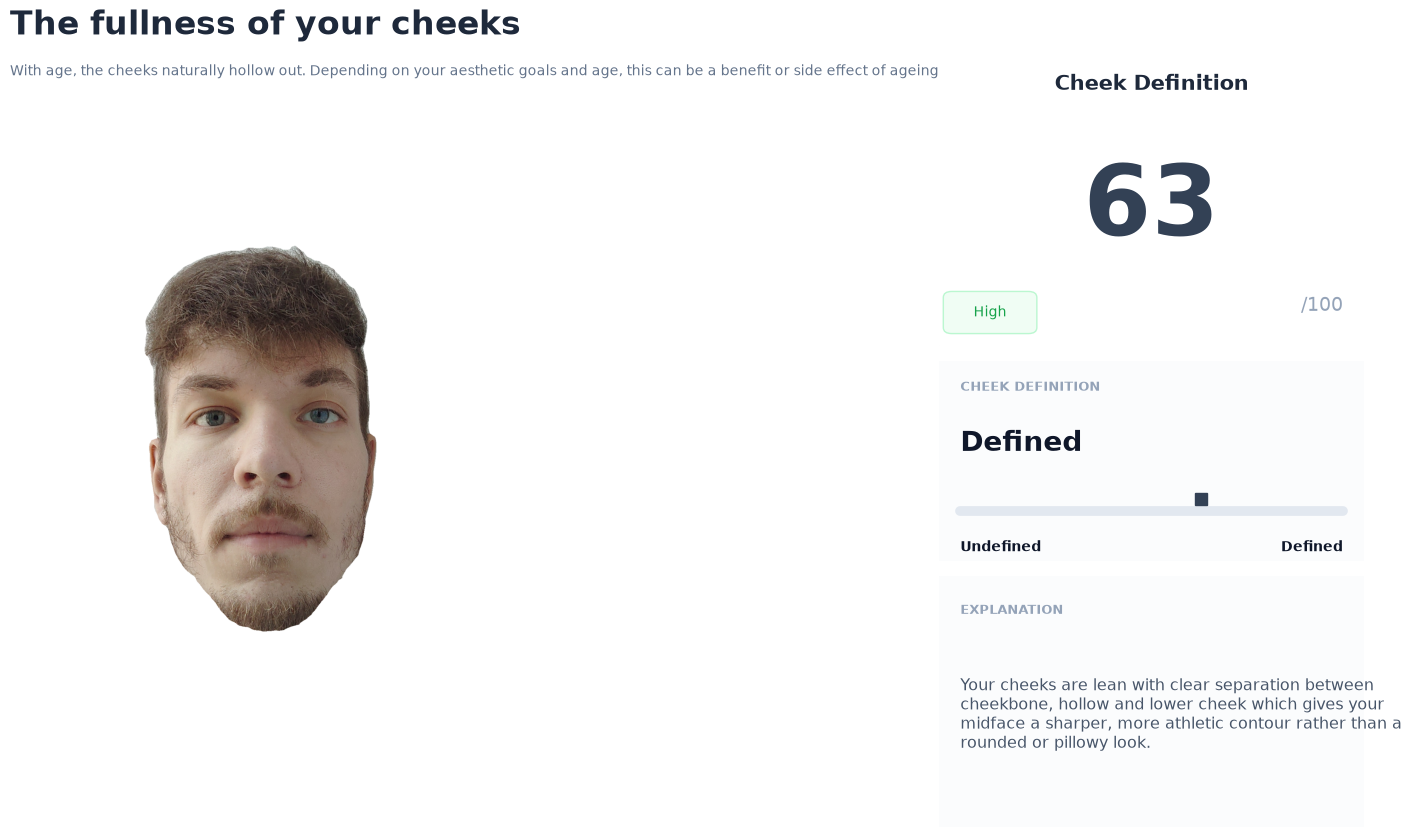

CHEEK DEFINITION SCORE: 63/100 (Defined)
  Factor 1 - Zygomatic/Gonion Ratio: 1.077 -> 9.1/100
  Factor 2 - Cheek Hollow Depth:     0.1297 -> 100.0/100
  Factor 3 - Midface Height/Width:   0.545 -> 100.0/100
  Composite: 0.40x9.1 + 0.35x100.0 + 0.25x100.0 = 63
Your cheeks are lean with clear separation between cheekbone, hollow and lower cheek which gives your midface a sharper, more athletic contour rather than a rounded or pillowy look.


In [9]:
# --- 14. CHEEK FULLNESS & DEFINITION ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

if 'landmarks' in locals():
    h, w, _ = image_rgb.shape
    def get_pt(idx):
        return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

    # ========================================================================
    # CHEEK DEFINITION SCORE - Multi-Factor Dynamic Calculation
    # ========================================================================
    # Factor 1: Zygomatic-to-Gonion Width Ratio (ZGR) - 40%
    # Factor 2: Cheek Hollow Depth (CHD) - 35%
    # Factor 3: Midface Height-to-Width Ratio (MHW) - 25%
    # ========================================================================

    # --- Factor 1: Zygomatic-to-Gonion Width Ratio ---
    zyg_r, zyg_l = get_pt(234), get_pt(454)
    gon_r, gon_l = get_pt(58), get_pt(288)
    zyg_width = np.linalg.norm(zyg_r - zyg_l)
    gon_width = np.linalg.norm(gon_r - gon_l)
    zgr = zyg_width / (gon_width + 1e-6)
    zgr_score = np.clip((zgr - 1.05) / (1.35 - 1.05), 0, 1) * 100

    # --- Factor 2: Cheek Hollow Depth ---
    def point_to_line_dist(p, a, b):
        # Perpendicular distance from point p to line segment a-b
        ab = b - a
        ap = p - a
        t = np.dot(ap, ab) / (np.dot(ab, ab) + 1e-6)
        t = np.clip(t, 0, 1)
        proj = a + t * ab
        return np.linalg.norm(p - proj)

    depth_r = point_to_line_dist(get_pt(216), get_pt(116), get_pt(58))
    depth_l = point_to_line_dist(get_pt(436), get_pt(345), get_pt(288))
    avg_depth = (depth_r + depth_l) / 2.0
    face_height = np.linalg.norm(get_pt(10) - get_pt(152))
    norm_depth = avg_depth / (face_height + 1e-6)
    chd_score = np.clip((norm_depth - 0.02) / (0.07 - 0.02), 0, 1) * 100

    # --- Factor 3: Midface Height-to-Width Ratio ---
    nasion = get_pt(9)
    subnasale = get_pt(2)
    midface_height = np.linalg.norm(nasion - subnasale)
    mhw = midface_height / (zyg_width + 1e-6)
    mhw_score = np.clip((mhw - 0.30) / (0.50 - 0.30), 0, 1) * 100

    # --- Composite Score ---
    score = int(np.clip(0.40 * zgr_score + 0.35 * chd_score + 0.25 * mhw_score, 0, 100))

    if score >= 80:
        level = 'Very High'
        category = 'Highly Defined'
        explanation = 'Your cheeks are extremely lean with a highly pronounced separation between the cheekbone and hollows, giving a striking, chiseled contour.'
    elif score >= 60:
        level = 'High'
        category = 'Defined'
        explanation = 'Your cheeks are lean with clear separation between cheekbone, hollow and lower cheek which gives your midface a sharper, more athletic contour rather than a rounded or pillowy look.'
    elif score >= 40:
        level = 'Average'
        category = 'Moderate'
        explanation = 'Your cheeks have a balanced fullness, offering a mix of youthful volume and subtle contour without being overly sharp or heavily rounded.'
    else:
        level = 'Low'
        category = 'Undefined'
        explanation = 'Your midface carries more volume, resulting in a softer, fuller, and more rounded contour that often conveys a highly youthful and pillowy appearance.'

    # --- UI Rendering ---
    fig = plt.figure(figsize=(14, 9))
    fig.patch.set_facecolor('#ffffff')
    gs = fig.add_gridspec(3, 2, width_ratios=[1.2, 1], height_ratios=[1.2, 0.8, 1])

    # Image
    ax_img = fig.add_subplot(gs[:, 0])
    display_img = cutout_image if 'cutout_image' in dir() else image_rgb
    ax_img.imshow(display_img)
    ax_img.axis('off')

    # Title
    ax_img.text(0.0, 1.09, 'The fullness of your cheeks', transform=ax_img.transAxes, fontsize=24, color='#1e293b', fontweight='bold')
    ax_img.text(0.0, 1.03, 'With age, the cheeks naturally hollow out. Depending on your aesthetic goals and age, this can be a benefit or side effect of ageing.', transform=ax_img.transAxes, fontsize=10, color='#64748b')

    # --- Card 1: Score ---
    ax_c1 = fig.add_subplot(gs[0, 1])
    ax_c1.axis('off')
    ax_c1.set_xlim(0, 1)
    ax_c1.set_ylim(0, 1)
    card_bg = mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle='round,pad=0.03', facecolor='#ffffff', edgecolor='#e2e8f0', lw=1)
    ax_c1.add_patch(card_bg)
    ax_c1.text(0.5, 0.85, 'Cheek Definition', fontsize=15, color='#1e293b', ha='center', fontweight='bold', transform=ax_c1.transAxes)
    ax_c1.text(0.5, 0.45, f'{score}', fontsize=70, color='#334155', ha='center', va='center', fontweight='bold', transform=ax_c1.transAxes)
    pill_bg = mpatches.FancyBboxPatch((0.03, 0.06), 0.18, 0.1, boxstyle='round,pad=0.02', facecolor='#f0fdf4', edgecolor='#bbf7d0', lw=1)
    ax_c1.add_patch(pill_bg)
    ax_c1.text(0.12, 0.11, level, fontsize=10, color='#16a34a', ha='center', va='center', transform=ax_c1.transAxes)
    ax_c1.text(0.95, 0.1, '/100', fontsize=14, color='#94a3b8', ha='right', va='bottom', transform=ax_c1.transAxes)

    # --- Card 2: Slider ---
    ax_c2 = fig.add_subplot(gs[1, 1])
    ax_c2.axis('off')
    ax_c2.set_xlim(0, 1)
    ax_c2.set_ylim(0, 1)
    card_bg2 = mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle='round,pad=0.03', facecolor='#fbfcfd', edgecolor='#edf2f7', lw=1)
    ax_c2.add_patch(card_bg2)
    ax_c2.text(0.05, 0.85, 'CHEEK DEFINITION', fontsize=9, color='#94a3b8', fontweight='bold', transform=ax_c2.transAxes)
    ax_c2.text(0.05, 0.55, category, fontsize=20, color='#0f172a', fontweight='bold', transform=ax_c2.transAxes)

    slider_y = 0.25
    ax_c2.plot([0.05, 0.95], [slider_y, slider_y], color='#e2e8f0', lw=7, solid_capstyle='round', transform=ax_c2.transAxes)
    tick_x = 0.05 + (score / 100.0) * 0.90
    ax_c2.plot([tick_x], [slider_y + 0.06], marker='s', markersize=8, color='#334155', transform=ax_c2.transAxes, zorder=5)
    ax_c2.text(0.05, 0.05, 'Undefined', fontsize=10, color='#0f172a', fontweight='bold', ha='left', transform=ax_c2.transAxes)
    ax_c2.text(0.95, 0.05, 'Defined', fontsize=10, color='#0f172a', fontweight='bold', ha='right', transform=ax_c2.transAxes)

    # --- Card 3: Explanation ---
    ax_c3 = fig.add_subplot(gs[2, 1])
    ax_c3.axis('off')
    ax_c3.set_xlim(0, 1)
    ax_c3.set_ylim(0, 1)
    card_bg3 = mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle='round,pad=0.03', facecolor='#fbfcfd', edgecolor='#edf2f7', lw=1)
    ax_c3.add_patch(card_bg3)
    ax_c3.text(0.05, 0.85, 'EXPLANATION', fontsize=9, color='#94a3b8', fontweight='bold', transform=ax_c3.transAxes)
    wrapped_exp = textwrap.fill(explanation, width=55)
    ax_c3.text(0.05, 0.60, wrapped_exp, fontsize=11.5, color='#475569', transform=ax_c3.transAxes, va='top')

    plt.tight_layout()
    plt.show()

    print('=' * 80)
    print(f'CHEEK DEFINITION SCORE: {score}/100 ({category})')
    print(f'  Factor 1 - Zygomatic/Gonion Ratio: {zgr:.3f} -> {zgr_score:.1f}/100')
    print(f'  Factor 2 - Cheek Hollow Depth:     {norm_depth:.4f} -> {chd_score:.1f}/100')
    print(f'  Factor 3 - Midface Height/Width:   {mhw:.3f} -> {mhw_score:.1f}/100')
    print(f'  Composite: 0.40x{zgr_score:.1f} + 0.35x{chd_score:.1f} + 0.25x{mhw_score:.1f} = {score}')
    print(explanation)
    print('=' * 80)
else:
    print('Run the previous cells first to generate landmarks!')

C:\Users\PratikJPatel\AppData\Local\Temp\ipykernel_14168\2305873967.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


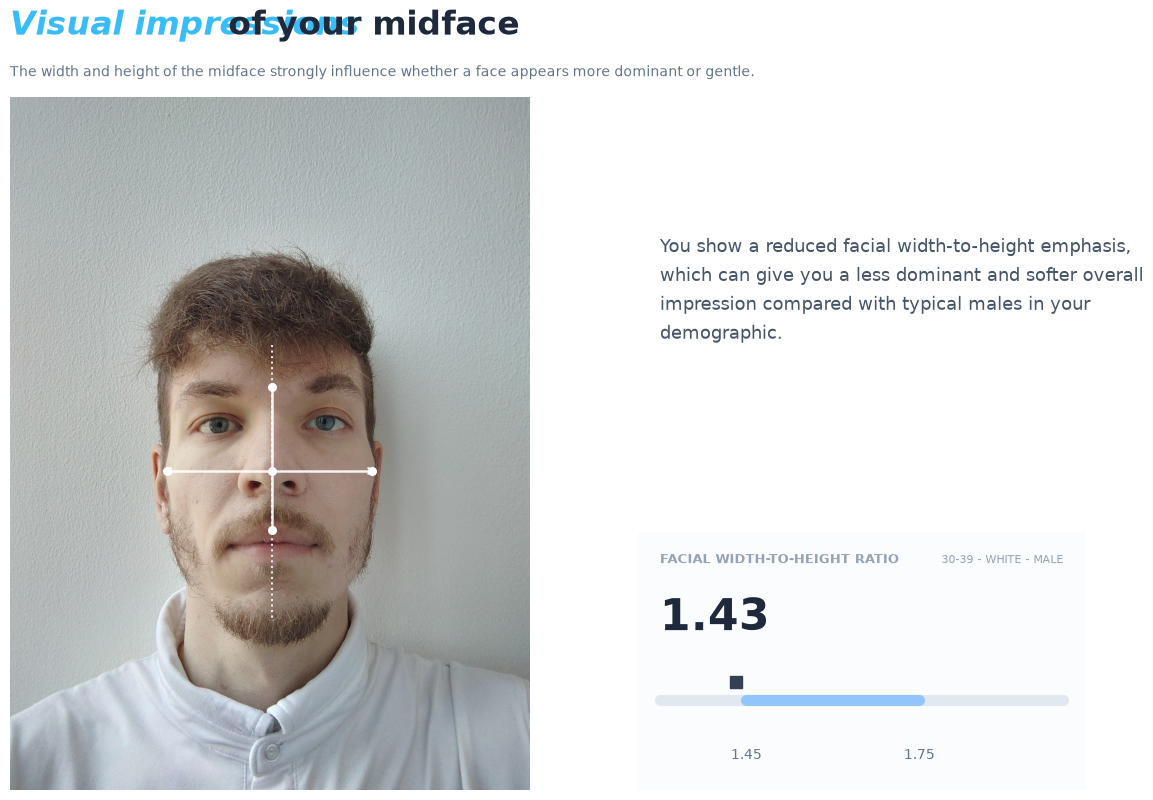

FACIAL WIDTH-TO-HEIGHT RATIO (fWHR): 1.43
  Bizygomatic Width: 590.9px
  Midface Height:    412.5px
  Impression: reduced emphasis -> less dominant and softer
You show a reduced facial width-to-height emphasis, which can give you a less dominant and softer overall impression compared with typical males in your demographic.


In [10]:
# --- 15. MIDFACE VISUAL IMPRESSIONS (fWHR) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

if 'landmarks' in locals():
    h, w, _ = image_rgb.shape
    def get_pt(idx):
        return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

    # ========================================================================
    # FACIAL WIDTH-TO-HEIGHT RATIO (fWHR)
    # ========================================================================
    # Width:  Bizygomatic width (landmark 234 to 454)
    # Height: Upper lip (landmark 0) to mid-brow (landmark 9)
    # fWHR = Width / Height
    # Typical male range: ~1.45 to ~1.95
    # Higher fWHR = wider, more dominant appearing face
    # Lower fWHR  = narrower, softer appearing face
    # ========================================================================

    # Key landmarks
    zyg_r = get_pt(234)   # Right zygion (widest cheek)
    zyg_l = get_pt(454)   # Left zygion
    brow_mid = get_pt(9)  # Mid-brow / glabella
    upper_lip = get_pt(0) # Upper lip vermilion border

    # Measurements
    face_width = np.linalg.norm(zyg_r - zyg_l)
    midface_height = np.linalg.norm(brow_mid - upper_lip)
    fwhr = face_width / (midface_height + 1e-6)

    # Interpretation
    # Average male fWHR is about 1.80; female about 1.75
    avg_male = 1.75
    if fwhr >= avg_male + 0.10:
        emphasis = 'increased'
        impression = 'more dominant and assertive'
        desc = f'You show an increased facial width-to-height emphasis, which can give you a more dominant and assertive overall impression compared with typical males in your demographic.'
    elif fwhr >= avg_male - 0.10:
        emphasis = 'average'
        impression = 'balanced'
        desc = f'You show a balanced facial width-to-height emphasis, giving you a neutral and proportionate overall impression that is typical of males in your demographic.'
    else:
        emphasis = 'reduced'
        impression = 'less dominant and softer'
        desc = f'You show a reduced facial width-to-height emphasis, which can give you a less dominant and softer overall impression compared with typical males in your demographic.'

    # --- Geometry overlay points ---
    # Horizontal line at zygomatic width
    zyg_y_avg = (zyg_r[1] + zyg_l[1]) / 2
    # Vertical line from brow to upper lip
    cx = (brow_mid[0] + upper_lip[0]) / 2

    # --- UI Rendering ---
    fig = plt.figure(figsize=(14, 9))
    fig.patch.set_facecolor('#ffffff')
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], height_ratios=[1.5, 1], hspace=0.15)

    # --- LEFT: Face image with geometry ---
    ax_img = fig.add_subplot(gs[:, 0])
    ax_img.imshow(image_rgb)
    ax_img.axis('off')
    ax_img.set_xlim(0, w)
    ax_img.set_ylim(h, 0)

    # Title
    ax_img.text(0.0, 1.09, 'Visual impressions ', transform=ax_img.transAxes, fontsize=24, color='#38bdf8', fontweight='bold', fontstyle='italic')
    ax_img.text(0.42, 1.09, 'of your midface', transform=ax_img.transAxes, fontsize=24, color='#1e293b', fontweight='bold')
    ax_img.text(0.0, 1.03, 'The width and height of the midface strongly influence whether a face appears more dominant or gentle.', transform=ax_img.transAxes, fontsize=10, color='#64748b')

    lc = '#ffffff'

    # 1. Vertical dotted centerline
    top_head = get_pt(10)
    chin = get_pt(152)
    ax_img.plot([cx, cx], [top_head[1], chin[1]], color=lc, linestyle=':', lw=1.5, alpha=0.85)

    # 2. Horizontal solid line at zygomatic level (the WIDTH)
    ax_img.plot([zyg_r[0], zyg_l[0]], [zyg_y_avg, zyg_y_avg], color=lc, lw=1.8, alpha=0.9)
    ax_img.annotate('', xy=(zyg_r[0] - 12, zyg_y_avg), xytext=(zyg_r[0], zyg_y_avg), arrowprops=dict(arrowstyle='->', color=lc, lw=1.5))
    ax_img.annotate('', xy=(zyg_l[0] + 12, zyg_y_avg), xytext=(zyg_l[0], zyg_y_avg), arrowprops=dict(arrowstyle='->', color=lc, lw=1.5))

    # 3. Vertical solid line from brow to upper lip (the HEIGHT)
    ax_img.plot([cx, cx], [brow_mid[1], upper_lip[1]], color=lc, lw=1.8, alpha=0.9)

    # 4. Small dots at intersection points
    ax_img.scatter([cx], [zyg_y_avg], s=30, color=lc, zorder=5)
    ax_img.scatter([cx], [brow_mid[1]], s=30, color=lc, zorder=5)
    ax_img.scatter([cx], [upper_lip[1]], s=30, color=lc, zorder=5)
    ax_img.scatter([zyg_r[0], zyg_l[0]], [zyg_y_avg, zyg_y_avg], s=30, color=lc, zorder=5)

    # --- RIGHT TOP: Explanation text ---
    ax_txt = fig.add_subplot(gs[0, 1])
    ax_txt.axis('off')
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)

    wrapped_desc = textwrap.fill(desc, width=55)
    ax_txt.text(0.05, 0.5, wrapped_desc, fontsize=13, color='#475569', transform=ax_txt.transAxes, va='center', linespacing=1.6)

    # --- RIGHT BOTTOM: Slider card ---
    ax_c = fig.add_subplot(gs[1, 1])
    ax_c.axis('off')
    ax_c.set_xlim(0, 1)
    ax_c.set_ylim(0, 1)

    card_bg = mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96, boxstyle='round,pad=0.03', facecolor='#fbfcfd', edgecolor='#edf2f7', lw=1)
    ax_c.add_patch(card_bg)

    ax_c.text(0.05, 0.88, 'FACIAL WIDTH-TO-HEIGHT RATIO', fontsize=9, color='#94a3b8', fontweight='bold', transform=ax_c.transAxes)
    ax_c.text(0.95, 0.88, '30-39 - WHITE - MALE', fontsize=8, color='#94a3b8', ha='right', transform=ax_c.transAxes)

    ax_c.text(0.05, 0.62, f'{fwhr:.2f}', fontsize=32, color='#1e293b', fontweight='bold', transform=ax_c.transAxes)

    # Horizontal slider
    slider_y = 0.35
    # Background bar (light gray)
    ax_c.plot([0.05, 0.95], [slider_y, slider_y], color='#e2e8f0', lw=8, solid_capstyle='round', transform=ax_c.transAxes, zorder=1)

    # Blue highlight zone (the typical range)
    range_low, range_high = 1.45, 1.75
    bar_left, bar_right = 0.05, 0.95
    bar_span = bar_right - bar_left
    display_min, display_max = 1.30, 2.00

    def val_to_x(v):
        return bar_left + (v - display_min) / (display_max - display_min) * bar_span

    blue_x0 = max(bar_left, val_to_x(range_low))
    blue_x1 = min(bar_right, val_to_x(range_high))
    ax_c.plot([blue_x0, blue_x1], [slider_y, slider_y], color='#93c5fd', lw=8, solid_capstyle='round', transform=ax_c.transAxes, zorder=2)

    # Tick marker at user score
    tick_x = np.clip(val_to_x(fwhr), bar_left, bar_right)
    ax_c.plot([tick_x], [slider_y + 0.07], marker='s', markersize=8, color='#334155', transform=ax_c.transAxes, zorder=5)

    # Range labels
    ax_c.text(blue_x0, 0.12, f'{range_low:.2f}', fontsize=10, color='#64748b', ha='center', transform=ax_c.transAxes)
    ax_c.text(blue_x1, 0.12, f'{range_high:.2f}', fontsize=10, color='#64748b', ha='center', transform=ax_c.transAxes)

    plt.tight_layout()
    plt.show()

    print('=' * 80)
    print(f'FACIAL WIDTH-TO-HEIGHT RATIO (fWHR): {fwhr:.2f}')
    print(f'  Bizygomatic Width: {face_width:.1f}px')
    print(f'  Midface Height:    {midface_height:.1f}px')
    print(f'  Impression: {emphasis} emphasis -> {impression}')
    print(desc)
    print('=' * 80)
else:
    print('Run the previous cells first to generate landmarks!')